## Impórts 

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## Deteccion de carpeta raiz

In [3]:
def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("No pude encontrar la raíz del proyecto.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
MANIFESTS_DIR = DATA_DIR / "manifests"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MANIFESTS_DIR:", MANIFESTS_DIR)

PROJECT_ROOT: /mnt/d/Universidad/analitica/proyecto_analitica2
DATA_DIR: /mnt/d/Universidad/analitica/proyecto_analitica2/data
MANIFESTS_DIR: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests


## cargar manifiesto de ISIC

In [4]:
manifest_path = MANIFESTS_DIR / "manifest_isic_master.csv"
df = pd.read_csv(manifest_path)

print("Manifest cargado:", manifest_path)
print("Shape:", df.shape)
df.head()

Manifest cargado: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests/manifest_isic_master.csv
Shape: (25331, 23)


,image_name,file_path,target_label,labels_list,label_count,age_approx,anatom_site_general,lesion_id,sex,dataset_name,...,NV,BCC,AK,BKL,DF,VASC,SCC,UNK,group_id,split_final
0,ISIC_0000000,/mnt/d/Universidad/analitica/proyecto_analitic...,NV,['NV'],1,55.0,anterior torso,NaN,female,ISIC_2019,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ISIC_0000000,train
1,ISIC_0000001,/mnt/d/Universidad/analitica/proyecto_analitic...,NV,['NV'],1,30.0,anterior torso,NaN,female,ISIC_2019,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ISIC_0000001,train
2,ISIC_0000002,/mnt/d/Universidad/analitica/proyecto_analitic...,MEL,['MEL'],1,60.0,upper extremity,NaN,female,ISIC_2019,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ISIC_0000002,train
3,ISIC_0000003,/mnt/d/Universidad/analitica/proyecto_analitic...,NV,['NV'],1,30.0,upper extremity,NaN,male,ISIC_2019,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ISIC_0000003,train
4,ISIC_0000004,/mnt/d/Universidad/analitica/proyecto_analitic...,MEL,['MEL'],1,80.0,posterior torso,NaN,male,ISIC_2019,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ISIC_0000004,test


## visión general del dataset

In [5]:
print("Columnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

Columnas:
['image_name', 'file_path', 'target_label', 'labels_list', 'label_count', 'age_approx', 'anatom_site_general', 'lesion_id', 'sex', 'dataset_name', 'modality', 'dimension', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK', 'group_id', 'split_final']

Tipos de datos:
image_name              object
file_path               object
target_label            object
labels_list             object
label_count              int64
age_approx             float64
anatom_site_general     object
lesion_id               object
sex                     object
dataset_name            object
modality                object
dimension               object
MEL                    float64
NV                     float64
BCC                    float64
AK                     float64
BKL                    float64
DF                     float64
VASC                   float64
SCC                    float64
UNK                    float64
group_id                object
split_final             object


## Datos faltantes

In [6]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
})

display(missing_summary)

,missing_count,missing_pct
anatom_site_general,2631,10.39
lesion_id,2084,8.23
age_approx,437,1.73
sex,384,1.52
file_path,0,0.00
target_label,0,0.00
image_name,0,0.00
labels_list,0,0.00
label_count,0,0.00
dataset_name,0,0.00


## distribución global de clases

In [7]:
class_counts = df["target_label"].value_counts().sort_values(ascending=False)
class_pct = (df["target_label"].value_counts(normalize=True) * 100).sort_values(ascending=False).round(2)

class_summary = pd.DataFrame({
    "count": class_counts,
    "pct": class_pct
})

display(class_summary)

,count,pct
target_label,,
NV,12875,50.83
MEL,4522,17.85
BCC,3323,13.12
BKL,2624,10.36
AK,867,3.42
SCC,628,2.48
VASC,253,1.00
DF,239,0.94


## gráfico de clases

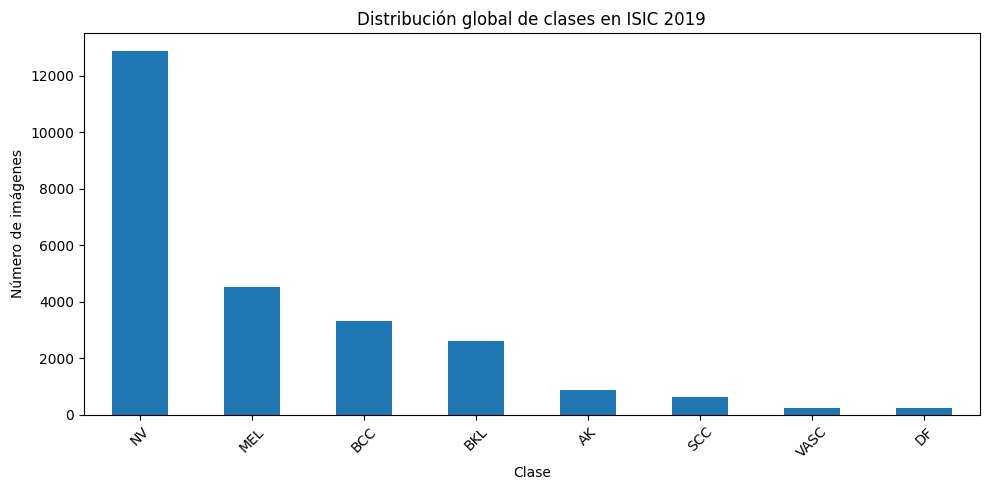

In [8]:
plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.title("Distribución global de clases en ISIC 2019")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## distribución de clases por split

In [9]:
split_class_counts = pd.crosstab(df["split_final"], df["target_label"])
display(split_class_counts)

target_label,AK,BCC,BKL,DF,MEL,NV,SCC,VASC
split_final,,,,,,,,
test,105,526,450,23,694,1880,94,35
train,617,2272,1836,169,3152,9053,410,173
val,145,525,338,47,676,1942,124,45


## gráfico por split

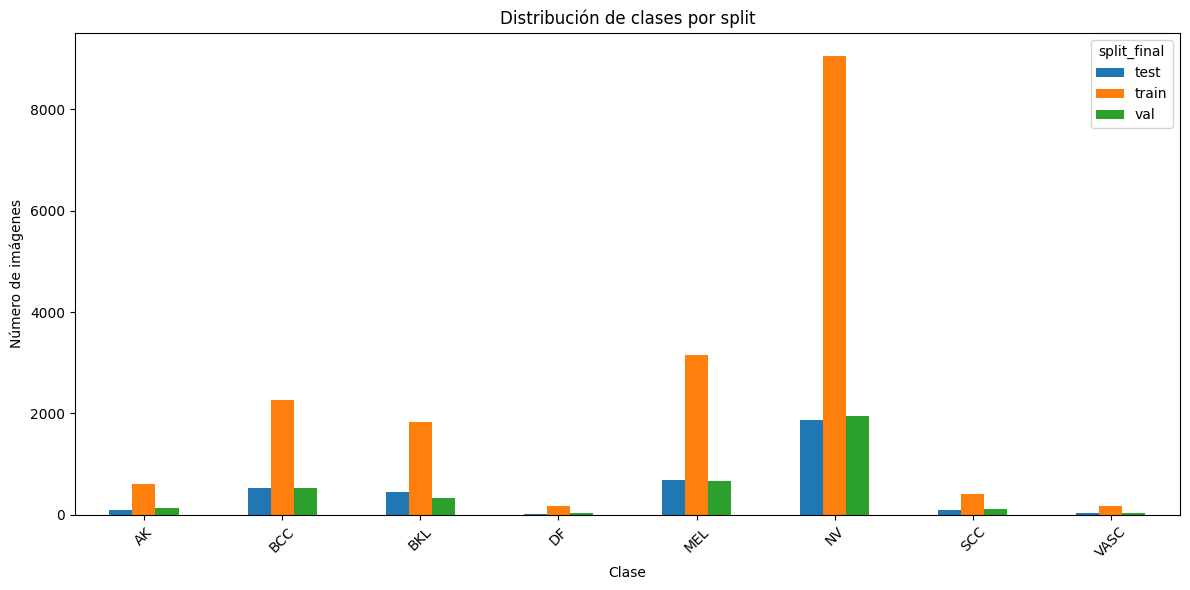

In [10]:
split_class_counts.T.plot(kind="bar", figsize=(12, 6))
plt.title("Distribución de clases por split")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Desbalanceo por clases categoricas

In [11]:
print("Distribución de sex:")
display(df["sex"].value_counts(dropna=False))

print("\nDistribución de anatom_site_general:")
display(df["anatom_site_general"].value_counts(dropna=False).head(20))

Distribución de sex:


sex
male      13286
female    11661
NaN         384
Name: count, dtype: int64


Distribución de anatom_site_general:


anatom_site_general
anterior torso     6915
lower extremity    4990
head/neck          4587
upper extremity    2910
posterior torso    2787
NaN                2631
palms/soles         398
oral/genital         59
lateral torso        54
Name: count, dtype: int64

## faltantes en metadata importante

In [12]:
feature_cols = ["sex", "age_approx", "anatom_site_general", "lesion_id"]

feature_missing = pd.DataFrame({
    "missing_count": df[feature_cols].isna().sum(),
    "missing_pct": (df[feature_cols].isna().mean() * 100).round(2)
})

display(feature_missing)

,missing_count,missing_pct
sex,384,1.52
age_approx,437,1.73
anatom_site_general,2631,10.39
lesion_id,2084,8.23


## edad aproximada

Resumen de age_approx:


count    24894.000000
mean        54.028481
std         18.130971
min          0.000000
25%         40.000000
50%         55.000000
75%         70.000000
max         85.000000
Name: age_approx, dtype: float64

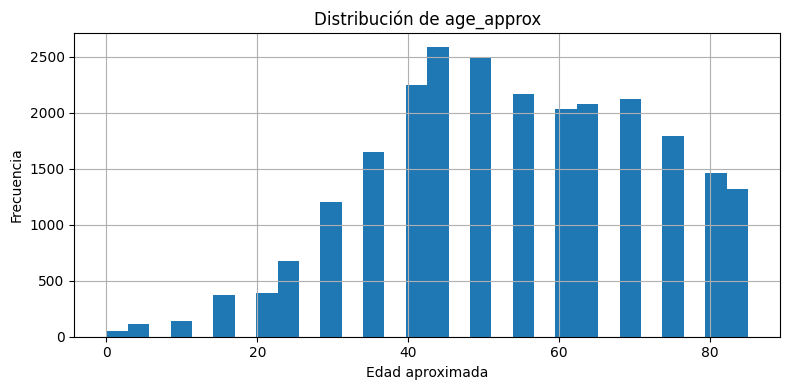

In [13]:
print("Resumen de age_approx:")
display(df["age_approx"].describe())

plt.figure(figsize=(8, 4))
df["age_approx"].dropna().hist(bins=30)
plt.title("Distribución de age_approx")
plt.xlabel("Edad aproximada")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## revisar repetición por lesión

In [14]:
lesion_counts = df["lesion_id"].fillna("MISSING_LESION").value_counts()

print("Resumen de imágenes por lesion_id:")
display(lesion_counts.describe())

print("\nTop 10 lesion_id con más imágenes:")
display(lesion_counts.head(10))

Resumen de imágenes por lesion_id:


count    11848.000000
mean         2.137998
std         19.214988
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max       2084.000000
Name: count, dtype: float64


Top 10 lesion_id con más imágenes:


lesion_id
MISSING_LESION    2084
BCN_0001728         31
BCN_0003369         27
BCN_0001321         26
BCN_0003196         24
BCN_0001954         21
BCN_0005108         20
BCN_0000861         20
BCN_0003907         20
BCN_0001755         20
Name: count, dtype: int64

## revisar file_path

In [15]:
missing_paths = df["file_path"].isna().sum()
print("Cantidad de file_path faltantes:", missing_paths)

if missing_paths > 0:
    display(df[df["file_path"].isna()].head())

Cantidad de file_path faltantes: 0


## tamaños de imagen en una muestra

In [16]:
sample_paths = df["file_path"].dropna().sample(
    n=min(200, df["file_path"].notna().sum()),
    random_state=42
)

image_sizes = []
for p in sample_paths:
    try:
        with Image.open(p) as img:
            image_sizes.append(img.size)
    except Exception:
        image_sizes.append((None, None))

sizes_df = pd.DataFrame(image_sizes, columns=["width", "height"])

print("Resumen tamaños de imagen:")
display(sizes_df.describe())

Resumen tamaños de imagen:


,width,height
count,200.000000,200.000000
mean,841.295000,733.330000
std,208.629406,266.758282
min,600.000000,450.000000
25%,600.000000,450.000000
50%,1024.000000,680.000000
75%,1024.000000,1024.000000
max,1024.000000,1024.000000


## Grafico de tamaños

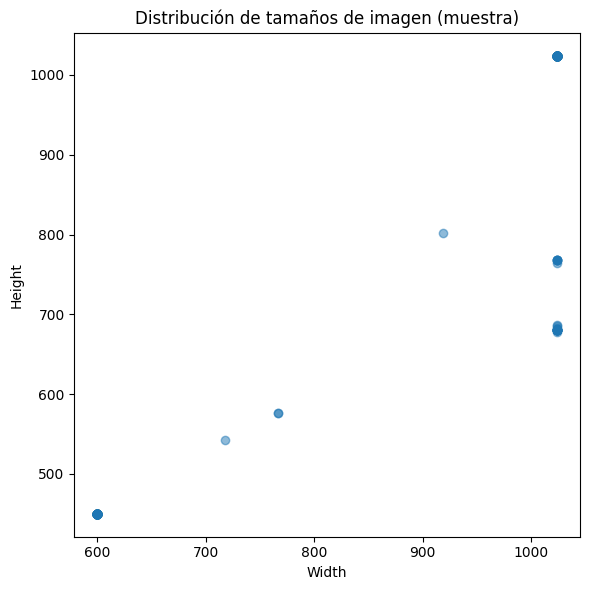

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(sizes_df["width"], sizes_df["height"], alpha=0.5)
plt.title("Distribución de tamaños de imagen (muestra)")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()
plt.show()

## ejemplos visuales por clase

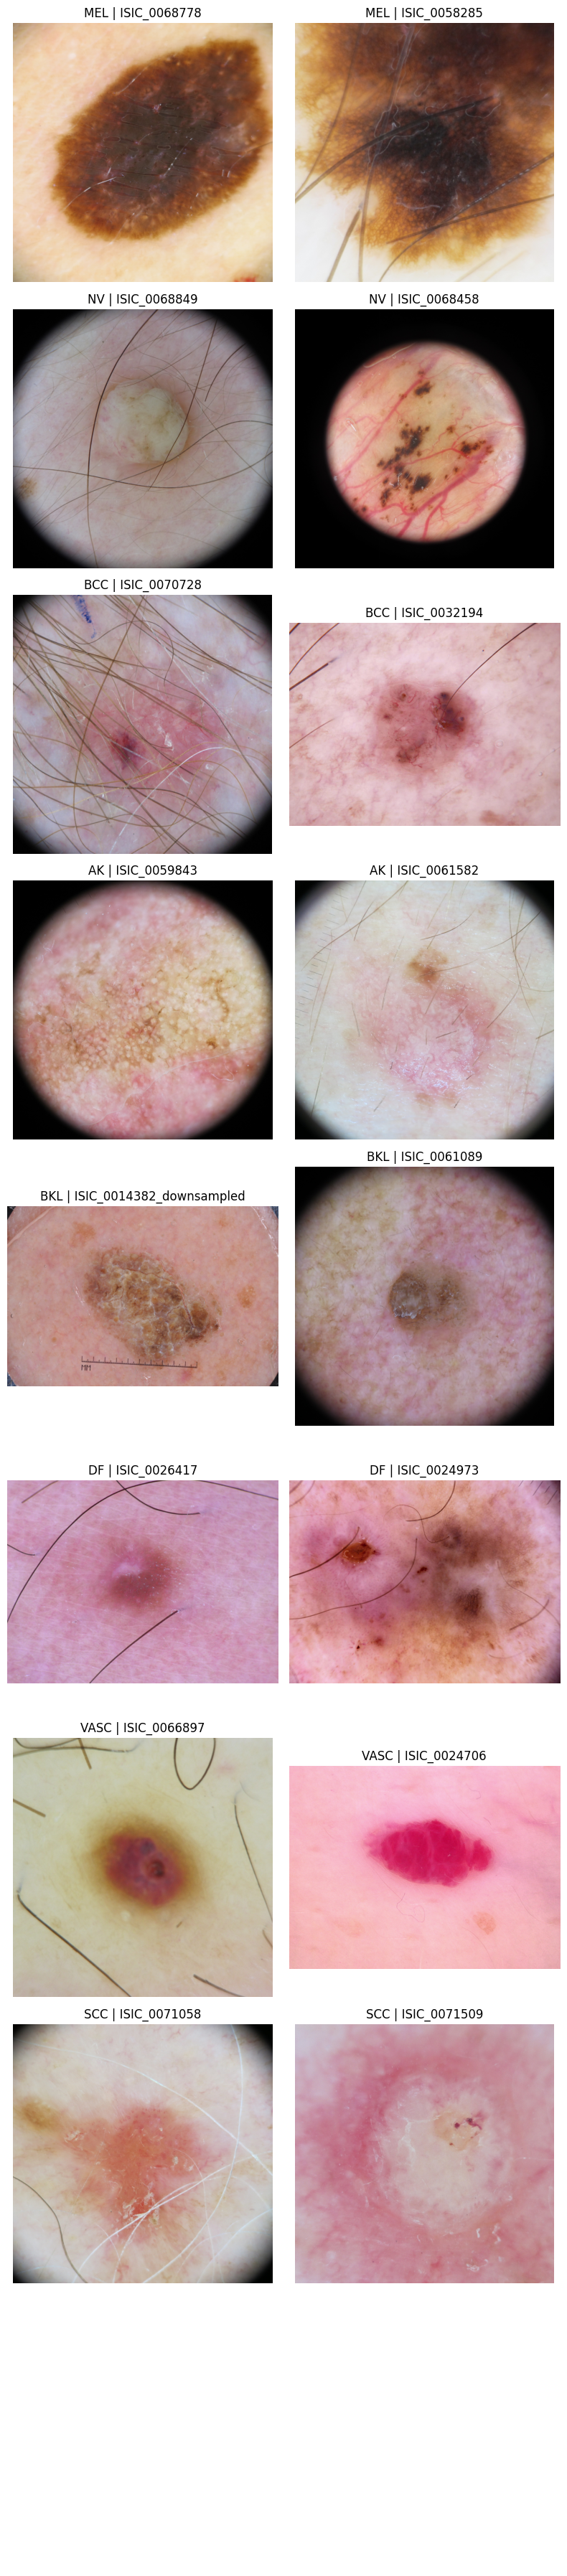

In [18]:
class_names = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC", "UNK"]

fig, axes = plt.subplots(len(class_names), 2, figsize=(8, 4 * len(class_names)))

for i, cls in enumerate(class_names):
    cls_df = df[df["target_label"] == cls].dropna(subset=["file_path"])
    samples = cls_df.sample(n=min(2, len(cls_df)), random_state=42)

    for j in range(2):
        ax = axes[i, j]
        ax.axis("off")

        if j < len(samples):
            img_path = samples.iloc[j]["file_path"]
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
            ax.set_title(f"{cls} | {samples.iloc[j]['image_name']}")

plt.tight_layout()
plt.show()